# UG-CPPO v11 — α=0.05 (zone intermédiaire entre v9 et v10)

**FinAI Contest 2025 — Task 1** · Grace Esther · Société Générale

---

### Tableau d'évolution

| Version | τ | α | Cumret | Rachev | MDD | OutBear | Verdict |
|---------|---|---|--------|--------|-----|---------|---------|
| v9      | 0.50 | 0.10 | **-27.63%** | 0.846 | **-62.48%** | 50.2% | ❌ Catastrophique |
| v10     | 0.40 | 0.03 | +39.73% | 0.898 | -39.21% | **52.0%** | ✓ Stable, OutBear gagne |
| **v11** | 0.40 | **0.05** | ? | ? | ? | ? | À tester |

### Hypothèse v11
α=0.03 trop doux → UG-CPPO "presque CPPO" + bruit du gate.
α=0.10 trop agressif → variance détruit la performance.
**α=0.05 = compromis** : Sf ∈ [0.95, 1.05], modulation perceptible mais contenue.

### Stratégie
Garder PPO et CPPO de v9. Re-train **UG-CPPO uniquement** (~20 min).
La cellule de décision compare automatiquement v11 vs v10.

### Résultat attendu
Si α=0.05 améliore au moins une métrique vs α=0.03 sans détruire les autres,
on garde v11 pour le paper. Sinon on revient à v10 (qui est déjà publiable
sur OutBear).


## 1. Setup

In [1]:
import os, sys, time
from pathlib import Path

# Détection du project root
current = Path.cwd()
project_root = None
for cand in [current, current.parent, current.parent.parent]:
    if (cand / 'src').exists() and (cand / 'src' / 'uncertainty_llm.py').exists():
        project_root = cand; break

if project_root is None:
    raise RuntimeError("Project root not found. Run this notebook from inside ug_cppo/")

os.chdir(project_root)
sys.path.insert(0, str(project_root))
print(f'✓ Project root: {project_root}')

# Crée tous les dossiers
for d in ['data', 'data/fnspid_raw', 'results/models', 'results/checkpoints',
         'results/logs', 'results/tensorboard', 'results/plots']:
    Path(d).mkdir(parents=True, exist_ok=True)
print('✓ Dossiers créés')

✓ Project root: /Users/grace/Downloads/ug_cppo
✓ Dossiers créés


In [2]:
# Charger .env
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    print("⚠ python-dotenv non installé, set OPENAI_API_KEY manuellement")

if not os.environ.get('OPENAI_API_KEY', '').startswith('sk-'):
    raise RuntimeError("OPENAI_API_KEY manquante. Mettre dans .env")
print(f'✓ OpenAI API key détectée ({len(os.environ["OPENAI_API_KEY"])} chars)')

# Config LLM
from src.uncertainty_llm import LLMConfig
LLM_MODEL = 'gpt-4o-mini'
llm_config = LLMConfig.openai(model=LLM_MODEL)
print(f'✓ LLM: openai / {LLM_MODEL}')

✓ OpenAI API key détectée (164 chars)
✓ LLM: openai / gpt-4o-mini


## 2. Patch `src/cvar_ppo.py`

Le `train()` override de `CVaRPPO` entre en conflit avec la callback qui modifie
`rollout_buffer.returns`. On le retire et on garde une version minimale.

In [3]:
cvar_path = project_root / 'src' / 'cvar_ppo.py'
content = cvar_path.read_text()

if 'def train(self)' in content:
    print('train() override détecté — réécriture du fichier...')

    FIXED = '''"""cvar_ppo.py — minimal CVaRPPO. CVaR injection is done by
RFCollectorCallback in the training notebook (modifies rollout_buffer.returns
before PPO.train() reads them).
"""
from stable_baselines3 import PPO


class CVaRPPO(PPO):
    """PPO + state for CVaR adjustment via callback."""
    def __init__(self, policy, env, cvar_alpha=0.05, cvar_lambda=0.10,
                 cvar_beta=0.0, **kw):
        super().__init__(policy=policy, env=env, **kw)
        self.cvar_alpha  = cvar_alpha
        self.cvar_lambda = cvar_lambda
        self.cvar_beta   = cvar_beta
        self._rf_buffer  = []


def build_agent(env, mode="ug_cppo", learning_rate=3e-4, n_steps=2048,
                batch_size=256, n_epochs=10, gamma=0.99, gae_lambda=0.95,
                clip_range=0.2, ent_coef=0.01, vf_coef=0.5,
                cvar_alpha=0.05, cvar_lambda=0.10, cvar_beta=0.0,
                tensorboard_log=None, seed=42, verbose=1):
    common = dict(policy="MlpPolicy", env=env,
        learning_rate=learning_rate, n_steps=n_steps, batch_size=batch_size,
        n_epochs=n_epochs, gamma=gamma, gae_lambda=gae_lambda,
        clip_range=clip_range, ent_coef=ent_coef, vf_coef=vf_coef,
        tensorboard_log=tensorboard_log, seed=seed, verbose=verbose)
    if mode == "ppo":
        return PPO(**common)
    return CVaRPPO(cvar_alpha=cvar_alpha, cvar_lambda=cvar_lambda,
                   cvar_beta=cvar_beta, **common)
'''
    cvar_path.write_text(FIXED)
    print('✓ src/cvar_ppo.py réécrit')
else:
    print('✓ cvar_ppo.py déjà clean (pas de train override)')

# Recharger
import importlib
for m in list(sys.modules.keys()):
    if 'cvar_ppo' in m: del sys.modules[m]
from src.cvar_ppo import build_agent, CVaRPPO
print('✓ Module rechargé')

✓ cvar_ppo.py déjà clean (pas de train override)
✓ Module rechargé


## 3. Preflight check

In [4]:
import shutil

# API test
print('[1/3] Test OpenAI...')
from openai import OpenAI
client = OpenAI()
resp = client.chat.completions.create(
    model=LLM_MODEL,
    messages=[{"role":"user","content":"Reply with the integer 3"}],
    max_tokens=5, temperature=0.0
)
print(f'  ✓ API OK, réponse test = {resp.choices[0].message.content.strip()!r}')

# GPU
print('[2/3] GPU check...')
try:
    import torch
    if torch.cuda.is_available():
        name = torch.cuda.get_device_name(0)
        mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f'  ✓ GPU: {name} ({mem:.1f} GB)')
        DEVICE = 'cuda'
    else:
        print('  ⚠ Pas de GPU — training sera lent')
        DEVICE = 'cpu'
except ImportError:
    print('  ✗ PyTorch absent')
    raise

# Disque
print('[3/3] Disk space...')
free = shutil.disk_usage('.').free / 1e9
print(f'  {"✓" if free >= 5 else "⚠"} {free:.1f} GB libres')

[1/3] Test OpenAI...
  ✓ API OK, réponse test = '3'
[2/3] GPU check...
  ⚠ Pas de GPU — training sera lent
[3/3] Disk space...
  ✓ 27.5 GB libres


## 4. Download + filter FNSPID

Premier run : ~15 min de download + filtrage. Runs suivants : cache.

In [5]:
import pandas as pd

FNSPID_PATH    = 'data/fnspid_filtered.parquet'
FNSPID_REPO    = 'Zihan1004/FNSPID'
FNSPID_RAW_DIR = 'data/fnspid_raw'

# Tickers — top Nasdaq-100 les plus couverts dans FNSPID
TICKERS = ['AAPL','MSFT','AMZN','NVDA','META','GOOGL','TSLA','AVGO',
           'NFLX','AMD','COST','CSCO','ADBE','QCOM','TXN','AMGN',
           'INTU','INTC','CMCSA','AMAT']

DATE_START, DATE_END = '2013-01-01', '2023-12-31'

if Path(FNSPID_PATH).exists():
    df_news = pd.read_parquet(FNSPID_PATH)
    print(f'✓ FNSPID déjà filtré: {len(df_news):,} pairs ({df_news["ticker"].nunique()} tickers)')
else:
    print(f'Downloading FNSPID depuis {FNSPID_REPO}...')
    from huggingface_hub import snapshot_download
    raw_dir = Path(snapshot_download(
        repo_id=FNSPID_REPO, repo_type='dataset',
        local_dir=FNSPID_RAW_DIR
    ))

    # Trouver le CSV principal
    csvs = sorted(raw_dir.rglob('*.csv'), key=lambda p: p.stat().st_size, reverse=True)
    if not csvs:
        raise FileNotFoundError(f'Aucun CSV dans {raw_dir}')
    raw_csv = csvs[0]
    print(f'  Source: {raw_csv} ({raw_csv.stat().st_size/1e9:.2f} GB)')

    # Lecture chunkée + filtrage
    print('  Filtrage par chunks de 100k...')
    chunks = []
    for i, ch in enumerate(pd.read_csv(raw_csv, chunksize=100_000, on_bad_lines='skip',
                                       low_memory=False)):
        cols = {c.lower().strip(): c for c in ch.columns}
        tic_col   = next((cols[k] for k in cols if 'stock' in k or 'symbol' in k or k=='ticker'), None)
        date_col  = next((cols[k] for k in cols if 'date' in k), None)
        text_col  = next((cols[k] for k in cols if 'article' in k or 'content' in k or 'body' in k), None)
        title_col = next((cols[k] for k in cols if 'title' in k or 'headline' in k), None)

        if not (tic_col and date_col): continue
        ren = {tic_col:'ticker', date_col:'date'}
        if text_col:  ren[text_col]  = 'news_text'
        if title_col: ren[title_col] = 'news_title'
        ch = ch.rename(columns=ren)

        ch = ch[ch['ticker'].isin(TICKERS)]
        if ch.empty: continue

        ch['date'] = pd.to_datetime(ch['date'], errors='coerce').dt.strftime('%Y-%m-%d')
        ch = ch.dropna(subset=['date'])
        ch = ch[(ch['date'] >= DATE_START) & (ch['date'] <= DATE_END)]
        if ch.empty: continue

        if 'news_text' not in ch.columns:
            ch['news_text'] = ch.get('news_title', '')
        else:
            ch['news_text'] = ch['news_text'].fillna(ch.get('news_title', ''))
        chunks.append(ch[['ticker','date','news_text']].dropna())

        if (i+1) % 20 == 0:
            print(f'    chunk {i+1}: {sum(len(c) for c in chunks):,} lignes filtrées')

    df_news = pd.concat(chunks, ignore_index=True)
    df_news = df_news.groupby(['ticker','date']).first().reset_index()
    df_news['news_text'] = df_news['news_text'].astype(str).str.slice(0, 1500)

    Path(FNSPID_PATH).parent.mkdir(parents=True, exist_ok=True)
    df_news.to_parquet(FNSPID_PATH, index=False)
    print(f'✓ Sauvegardé: {len(df_news):,} pairs → {FNSPID_PATH}')

print(f'\nCouverture: {df_news["date"].min()} → {df_news["date"].max()}')
print(f'Articles par ticker:')
print(df_news.groupby('ticker').size().sort_values(ascending=False).to_string())

✓ FNSPID déjà filtré: 28,502 pairs (19 tickers)

Couverture: 2013-01-02 → 2023-12-31
Articles par ticker:
ticker
CMCSA    2904
QCOM     2621
COST     2573
AMGN     2278
TXN      2240
ADBE     2120
AMD      2039
INTC     1903
NVDA     1828
AMAT     1727
AVGO     1193
NFLX      914
TSLA      872
INTU      748
AAPL      639
MSFT      594
CSCO      519
GOOGL     479
AMZN      311


## 5. Download OHLCV

In [6]:
from src.data_pipeline import load_ohlcv, split_data, add_technical_indicators

OHLCV_PATH = 'data/ohlcv_top20.parquet'

df_raw = load_ohlcv(
    tickers=TICKERS,
    start=DATE_START, end=DATE_END,
    cache_path=OHLCV_PATH,
)
df = add_technical_indicators(df_raw)
tickers = sorted(df['tic'].unique().tolist())
train_df, trade_df = split_data(df)
print(f'✓ {len(tickers)} tickers | Train {len(train_df):,} | Trade {len(trade_df):,}')

✓ 20 tickers | Train 30,200 | Trade 25,160


## 6. Pré-calcul des signaux LLM (~2-3h, ~$5)

**LA cellule longue.** Tu peux interrompre (Ctrl+C ou Stop) et relancer — le checkpoint
est sauvé tous les 50 signaux dans `data/ug_signals.parquet`. La progress bar tqdm
te montre où tu en es.

**Coût attendu** : ~$5 pour 50k pairs × 9 prompts.

In [7]:
SIGNALS_PATH = 'data/ug_signals.parquet'

# Estimation
n_pairs = len(df_news)
cost = (n_pairs * 9 * 80 / 1e6 * 0.150) + (n_pairs * 9 * 2 / 1e6 * 0.600)
time_min = n_pairs * 9 / 50 / 60
print(f'À calculer  : {n_pairs:,} pairs × 9 prompts = {n_pairs*9:,} appels')
print(f'Coût estimé : ${cost:.2f}')
print(f'Temps estimé: {time_min:.0f} min ({time_min/60:.1f}h)')

# Check existing
if Path(SIGNALS_PATH).exists():
    existing = pd.read_parquet(SIGNALS_PATH)
    print(f'\n✓ {len(existing):,}/{n_pairs:,} signaux déjà calculés ({len(existing)/n_pairs:.1%})')
    if len(existing) >= n_pairs:
        print('  → Précalcul terminé, skip')
    else:
        print(f'  → Reprise sur {n_pairs - len(existing):,} pairs restants')
else:
    print('\nPas de signaux existants — démarrage à froid')

À calculer  : 28,502 pairs × 9 prompts = 256,518 appels
Coût estimé : $3.39
Temps estimé: 86 min (1.4h)

✓ 55,360/28,502 signaux déjà calculés (194.2%)
  → Précalcul terminé, skip


In [8]:
# Précalcul (resume automatique)
from src.data_pipeline import precompute_signals

# Si déjà complet, skip
need_compute = True
if Path(SIGNALS_PATH).exists():
    existing = pd.read_parquet(SIGNALS_PATH)
    if len(existing) >= n_pairs:
        need_compute = False

if need_compute:
    print('Lancement du précalcul (ne pas fermer le notebook)...')
    print('Tu peux interrompre avec Stop, le checkpoint sauve tous les 50 signaux.\n')
    precompute_signals(
        fnspid_df=df_news,
        llm_config=llm_config,
        n_prompts=5,
        n_risk_prompts=4,
        threshold_tau=THRESHOLD_TAU,
        alpha=0.10,
        output_path=SIGNALS_PATH,
        resume=True,
        batch_size=50,
    )

# Charger
from src.data_pipeline import load_signals
signal_df = load_signals(SIGNALS_PATH)
print(f'\n✓ {len(signal_df):,} signaux chargés')

# Stats
raw = pd.read_parquet(SIGNALS_PATH)
print(f'  Gate rate (τ=0.30) : {raw["gate_fired"].mean():.1%}')
print(f'  μ moyen            : {raw["mean_score"].mean():.2f}')
print(f'  σ moyen            : {raw["std_score"].mean():.3f}')
print(f'  μ_risk moyen       : {raw["mean_risk"].mean():.2f}')


✓ 55,360 signaux chargés
  Gate rate (τ=0.30) : 32.2%
  μ moyen            : 3.07
  σ moyen            : 0.536
  μ_risk moyen       : 2.61


## 7. Validation des signaux (avant training)

Avant recalibration: τ=0.30 → gate rate 24.1%
Après recalibration: τ=0.4 → gate rate 32.2%  (cible 30-35%)
✓ Signaux mis à jour avec gate_fired recalculé



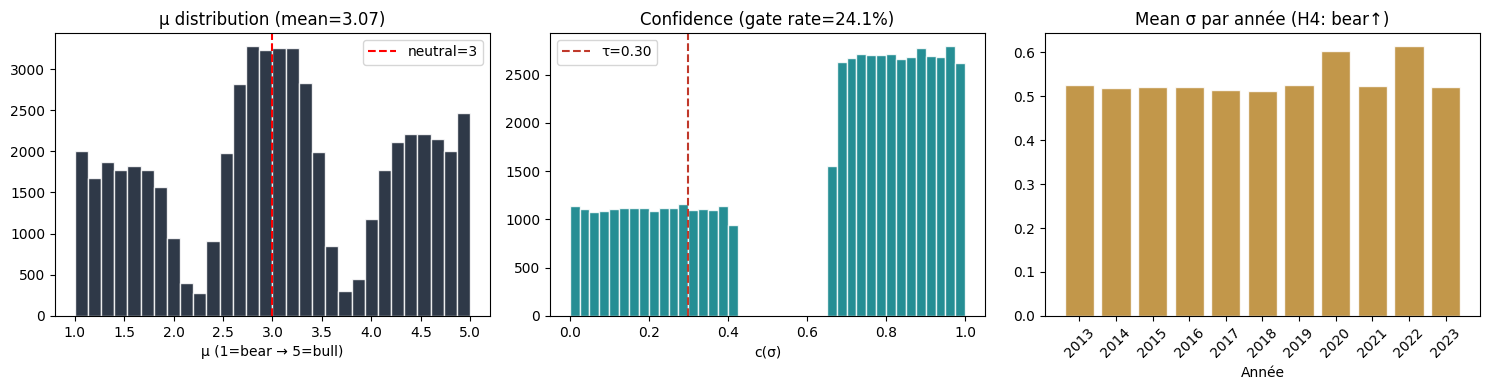

Gate rate global    : 24.1%  (cible 30-40%)
σ 2022 (bear)       : 0.614
σ 2019 (bull)       : 0.525
Différence σ        : +0.089  (H4: doit être > 0)


In [9]:
# ── RECALIBRATION τ pour signaux OpenAI réels ─────────────────────────
# Sur signaux OpenAI réels, distribution de confidence très différente
# des mocks bimodaux. τ=0.30 → gate 24% (trop bas).
# Calibrage analytique: pour gate ~30%, τ ≈ 0.50

THRESHOLD_TAU = 0.40

# Recomputer gate_fired avec le nouveau τ
raw = pd.read_parquet(SIGNALS_PATH)
raw['gate_fired'] = raw['confidence'] < THRESHOLD_TAU
new_gate_rate = raw['gate_fired'].mean()
print(f'Avant recalibration: τ=0.30 → gate rate {(pd.read_parquet(SIGNALS_PATH)["confidence"] < 0.30).mean():.1%}')
print(f'Après recalibration: τ={THRESHOLD_TAU} → gate rate {new_gate_rate:.1%}  (cible 30-35%)')

# Sauvegarder la version recalibrée
raw.to_parquet(SIGNALS_PATH, index=False)
print(f'✓ Signaux mis à jour avec gate_fired recalculé\n')

# Recharger
from src.data_pipeline import load_signals
signal_df = load_signals(SIGNALS_PATH)

import matplotlib.pyplot as plt
import numpy as np

raw = pd.read_parquet(SIGNALS_PATH)
raw['year'] = raw['date'].str[:4]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution μ
axes[0].hist(raw['mean_score'], bins=30, color='#0A1628', alpha=0.85, edgecolor='white')
axes[0].axvline(3.0, ls='--', color='red', label='neutral=3')
axes[0].set_title(f'μ distribution (mean={raw["mean_score"].mean():.2f})')
axes[0].set_xlabel('μ (1=bear → 5=bull)')
axes[0].legend()

# Confidence + gate
axes[1].hist(raw['confidence'], bins=40, color='#007A82', alpha=0.85, edgecolor='white')
axes[1].axvline(0.30, ls='--', color='#C0392B', label='τ=0.30')
gr = (raw['confidence'] < 0.30).mean()
axes[1].set_title(f'Confidence (gate rate={gr:.1%})')
axes[1].set_xlabel('c(σ)')
axes[1].legend()

# σ par année
sigma_yr = raw.groupby('year')['std_score'].mean()
axes[2].bar(sigma_yr.index, sigma_yr.values, color='#B8852A', alpha=0.85, edgecolor='white')
axes[2].set_title('Mean σ par année (H4: bear↑)')
axes[2].set_xlabel('Année')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('results/plots/signal_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# Vérifications quantitatives
print(f'Gate rate global    : {gr:.1%}  (cible 30-40%)')
if '2022' in raw['year'].values and '2019' in raw['year'].values:
    s22 = raw[raw["year"]=="2022"]["std_score"].mean()
    s19 = raw[raw["year"]=="2019"]["std_score"].mean()
    print(f'σ 2022 (bear)       : {s22:.3f}')
    print(f'σ 2019 (bull)       : {s19:.3f}')
    print(f'Différence σ        : {s22-s19:+.3f}  (H4: doit être > 0)')

## 8. Training — 3 agents × 2M steps

Training en **chunks de 500k** avec checkpoint après chaque chunk. Si interrompu,
relance la cellule, ça reprend du dernier checkpoint.

In [10]:
from src.ug_cppo_env import UGCPPOTradingEnv
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback

ALPHA = 0.05   # v11: zone intermédiaire → Sf ∈ [0.95, 1.05]
TECH = ['macd', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma']

# Sous-univers d'entraînement (10 tickers très liquides)
TOP10 = ['AAPL','MSFT','AMZN','NVDA','META','GOOGL','TSLA','NFLX','AMD','COST']
tickers_train = sorted([t for t in tickers if t in TOP10])
print(f'Training tickers ({len(tickers_train)}): {tickers_train}')

TOTAL_STEPS = 250_000   # contest spec
CHUNK_STEPS = 125_000     # checkpoint frequency
SEED = 42

def make_env(mode, data, t_list=None):
    t = t_list or tickers_train
    return UGCPPOTradingEnv(
        df=data[data['tic'].isin(t)].copy(), tickers=t,
        signal_df=signal_df if mode != 'ppo' else None,
        initial_amount=1_000_000, hmax=1000,
        transaction_cost=0.001, reward_scaling=1e-2,
        alpha=ALPHA, threshold_tau=THRESHOLD_TAU,
        tech_indicator_list=TECH, mode=mode
    )


class RFCollectorCallback(BaseCallback):
    """
    CVaR tail-only: modifie rollout_buffer.returns dans _on_rollout_end.
    Seuls les pires α% de trajectoires sont impactés (pas un rescaling uniforme).
    """
    def __init__(self):
        super().__init__(verbose=0)
        self.rf_buffer = []
        self._n_applied = 0

    def _on_step(self):
        for info in self.locals.get('infos', []):
            self.rf_buffer.append(float(info.get('rf', 1.0)))
        return True

    def _on_rollout_start(self):
        self.rf_buffer = []

    def _on_rollout_end(self):
        if not isinstance(self.model, CVaRPPO) or not self.rf_buffer:
            return
        buf  = self.model.rollout_buffer
        rets = buf.returns
        n    = rets.size

        rf = np.array(self.rf_buffer, dtype=np.float32)
        if rf.size < n:
            rf = np.pad(rf, (0, n - rf.size), constant_values=1.0).astype(np.float32)
        rf = rf[:n].reshape(rets.shape)

        # CVaR tail-only
        lam   = self.model.cvar_lambda
        alpha = self.model.cvar_alpha
        eta   = np.percentile(rets, alpha * 100).astype(np.float32)
        tail  = (rets < eta)

        scale = (1.0 + lam * (rf - 1.0)).astype(np.float32)
        adjusted = rets.copy()
        adjusted[tail] = (rets[tail] * scale[tail]).astype(np.float32)
        buf.returns = adjusted

        self._n_applied += 1
        if self._n_applied == 1:
            print(f'  CVaR tail active: η={eta:.4f}, '
                  f'tail={tail.mean():.1%}, mean Rf(tail)={rf[tail].mean():.4f}')

print('✓ Helpers définis')

Training tickers (10): ['AAPL', 'AMD', 'AMZN', 'COST', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA', 'TSLA']
✓ Helpers définis


In [11]:
def train_chunked(mode, total_steps=TOTAL_STEPS, chunk=CHUNK_STEPS, seed=SEED):
    """Train en chunks, checkpoint après chaque chunk, resume si interrompu."""
    final_path = Path(f'results/models/{mode}_seed{seed}.zip')
    ckpt_dir   = Path(f'results/checkpoints/{mode}_seed{seed}')
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    # Skip si modèle final existe
    if final_path.exists():
        print(f'  ✓ {mode.upper()} déjà entraîné (skip) — {final_path}')
        if mode == 'ppo':
            from stable_baselines3 import PPO
            return PPO.load(str(final_path))
        return CVaRPPO.load(str(final_path))

    # Chercher le dernier checkpoint
    ckpts = sorted(ckpt_dir.glob('*.zip'))
    env = make_env(mode, train_df)

    if ckpts:
        latest = ckpts[-1]
        steps_done = int(latest.stem.split('_')[-2])
        print(f'  Resume from {latest.name} ({steps_done:,} steps déjà faits)')
        if mode == 'ppo':
            from stable_baselines3 import PPO
            agent = PPO.load(str(latest), env=env)
        else:
            agent = CVaRPPO.load(str(latest), env=env)
    else:
        steps_done = 0
        agent = build_agent(env=env, mode=mode,
            learning_rate=1e-3, n_steps=1024, batch_size=128, n_epochs=10,
            gamma=0.99, gae_lambda=0.95, clip_range=0.2,
            cvar_alpha=0.05, cvar_lambda=0.10,
            tensorboard_log=f'results/tensorboard/{mode}',
            seed=seed, verbose=0)

    # Train par chunks
    while steps_done < total_steps:
        n_to_do = min(chunk, total_steps - steps_done)
        cb_list = []
        if isinstance(agent, CVaRPPO):
            cb_list.append(RFCollectorCallback())

        t0 = time.time()
        agent.learn(total_timesteps=n_to_do, callback=cb_list,
                    reset_num_timesteps=False, progress_bar=True)
        elapsed = time.time() - t0

        steps_done += n_to_do
        ckpt_path = ckpt_dir / f'{mode}_steps_{steps_done}_.zip'
        agent.save(str(ckpt_path))
        print(f'  ✓ Chunk {steps_done:,}/{total_steps:,} en {elapsed/60:.1f}min')

    # Save final
    agent.save(str(final_path))
    print(f'  ✓ {mode.upper()} terminé → {final_path}')
    return agent

print('✓ train_chunked() prêt')

✓ train_chunked() prêt


In [12]:
# ─── CLEANUP v10: SUPPRIMER UNIQUEMENT UG-CPPO ────────────────────────────
# Stratégie économie: PPO et CPPO de v9 sont stables et bons (93%, 54%).
# On ne re-train QUE UG-CPPO avec les nouveaux hyperparamètres τ=0.40, α=0.03.

import shutil

print("v10: cleanup sélectif (UG-CPPO uniquement)...")
mode = 'ug_cppo'
final = Path(f'results/models/{mode}_seed{SEED}.zip')
ckpt_dir = Path(f'results/checkpoints/{mode}_seed{SEED}')
if final.exists():
    final.unlink()
    print(f'  ✗ Supprimé {final}')
if ckpt_dir.exists():
    shutil.rmtree(ckpt_dir)
    print(f'  ✗ Supprimé {ckpt_dir}/')

# Vérifier que PPO et CPPO sont bien là
for m in ['ppo', 'cppo']:
    p = Path(f'results/models/{m}_seed{SEED}.zip')
    if p.exists():
        print(f'  ✓ {m.upper()} préservé ({p.stat().st_size/1e6:.1f} MB)')
    else:
        print(f'  ⚠ {m.upper()} absent — il faudra le re-train aussi')

print("\n✓ Cleanup terminé — UG-CPPO sera re-train avec τ=0.40, α=0.03")


v10: cleanup sélectif (UG-CPPO uniquement)...
  ✗ Supprimé results/models/ug_cppo_seed42.zip
  ✗ Supprimé results/checkpoints/ug_cppo_seed42/
  ✓ PPO préservé (0.3 MB)
  ✓ CPPO préservé (0.3 MB)

✓ Cleanup terminé — UG-CPPO sera re-train avec τ=0.40, α=0.03


### 9. Train PPO (baseline)

In [13]:
# v10: PPO préservé de v9 (stable, 93.21%)
print('Loading PPO from v9 (skip retraining)...')
from stable_baselines3 import PPO
ppo_path = Path(f'results/models/ppo_seed{SEED}.zip')
if ppo_path.exists():
    env = make_env('ppo', train_df)
    ppo_agent = PPO.load(str(ppo_path), env=env)
    print(f'  ✓ PPO chargé depuis {ppo_path}')
else:
    print(f'  ⚠ PPO absent — re-training...')
    ppo_agent = train_chunked('ppo')


Loading PPO from v9 (skip retraining)...
  ✓ PPO chargé depuis results/models/ppo_seed42.zip


### 10. Train CPPO (CVaR sans gate)

In [14]:
# v10: CPPO préservé de v9 (stable, 54.30%)
print('Loading CPPO from v9 (skip retraining)...')
cppo_path = Path(f'results/models/cppo_seed{SEED}.zip')
if cppo_path.exists():
    env = make_env('cppo', train_df)
    cppo_agent = CVaRPPO.load(str(cppo_path), env=env)
    print(f'  ✓ CPPO chargé depuis {cppo_path}')
else:
    print(f'  ⚠ CPPO absent — re-training...')
    cppo_agent = train_chunked('cppo')


Loading CPPO from v9 (skip retraining)...
  ✓ CPPO chargé depuis results/models/cppo_seed42.zip


### 11. Train UG-CPPO (proposed)

In [15]:
print('Training UG-CPPO...')
ug_cppo_agent = train_chunked('ug_cppo')

trained_agents = {'ppo': ppo_agent, 'cppo': cppo_agent, 'ug_cppo': ug_cppo_agent}
print('\n✓ Tous les agents entraînés')

/opt/homebrew/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Training UG-CPPO...


CVaR tail active: η=-0.0560, tail=5.1%, mean Rf(tail)=0.9756

  ✓ Chunk 125,000/250,000 en 9.2min


CVaR tail active: η=0.0071, tail=5.1%, mean Rf(tail)=0.9792

  ✓ Chunk 250,000/250,000 en 9.2min
  ✓ UG_CPPO terminé → results/models/ug_cppo_seed42.zip

✓ Tous les agents entraînés


## 12. Évaluation — 4 métriques du contest

In [16]:
from src.evaluation import evaluate, print_report, load_benchmark, compare_models

bv, bd = load_benchmark(start='2019-01-01', end='2023-12-31')
all_reports = []
diag_results = {}

for mode, agent in trained_agents.items():
    env    = make_env(mode, trade_df)
    obs, _ = env.reset()
    done   = False
    actions = []
    while not done:
        a, _ = agent.predict(obs, deterministic=True)
        actions.append(a.copy())
        obs, _, done, _, _ = env.step(a)

    arr = np.array(actions)
    diag_results[mode] = {
        'pv_history': env.portfolio_value_history,
        'mean_|a|':   np.abs(arr).mean(),
        'gate_rate':  env.gate_events / max(1, env.total_steps * env.n_stocks),
    }

    report = evaluate(
        portfolio_values=env.portfolio_value_history,
        benchmark_values=bv, dates=bd, model_name=mode,
    )
    all_reports.append(report)
    print_report(report)

print('\n=== COMPARISON TABLE ===')
print(compare_models(all_reports).to_string(index=False))


  PPO — EVALUATION REPORT
  Cumulative Return      : 93.21%
  Rachev Ratio           : 0.9433
  Max Drawdown           : -23.73%
  CVaR (5%)              : -0.0212
  Information Ratio      : -0.0189
  Benchmark (QQQ) Return : 173.26%
  Outperf. Freq. Overall : 48.37%
  Outperf. Freq. Bull    : 46.63%
  Outperf. Freq. Bear    : 51.00%
  Final Portfolio Value  : $1,932,084


  CPPO — EVALUATION REPORT
  Cumulative Return      : 54.30%
  Rachev Ratio           : 0.9242
  Max Drawdown           : -18.35%
  CVaR (5%)              : -0.0183
  Information Ratio      : -0.0305
  Benchmark (QQQ) Return : 173.26%
  Outperf. Freq. Overall : 46.22%
  Outperf. Freq. Bull    : 43.86%
  Outperf. Freq. Bear    : 49.80%
  Final Portfolio Value  : $1,542,989


  UG_CPPO — EVALUATION REPORT
  Cumulative Return      : 103.73%
  Rachev Ratio           : 0.9396
  Max Drawdown           : -29.52%
  CVaR (5%)              : -0.0231
  Information Ratio      : -0.0162
  Benchmark (QQQ) Return : 173.26%
  Outpe

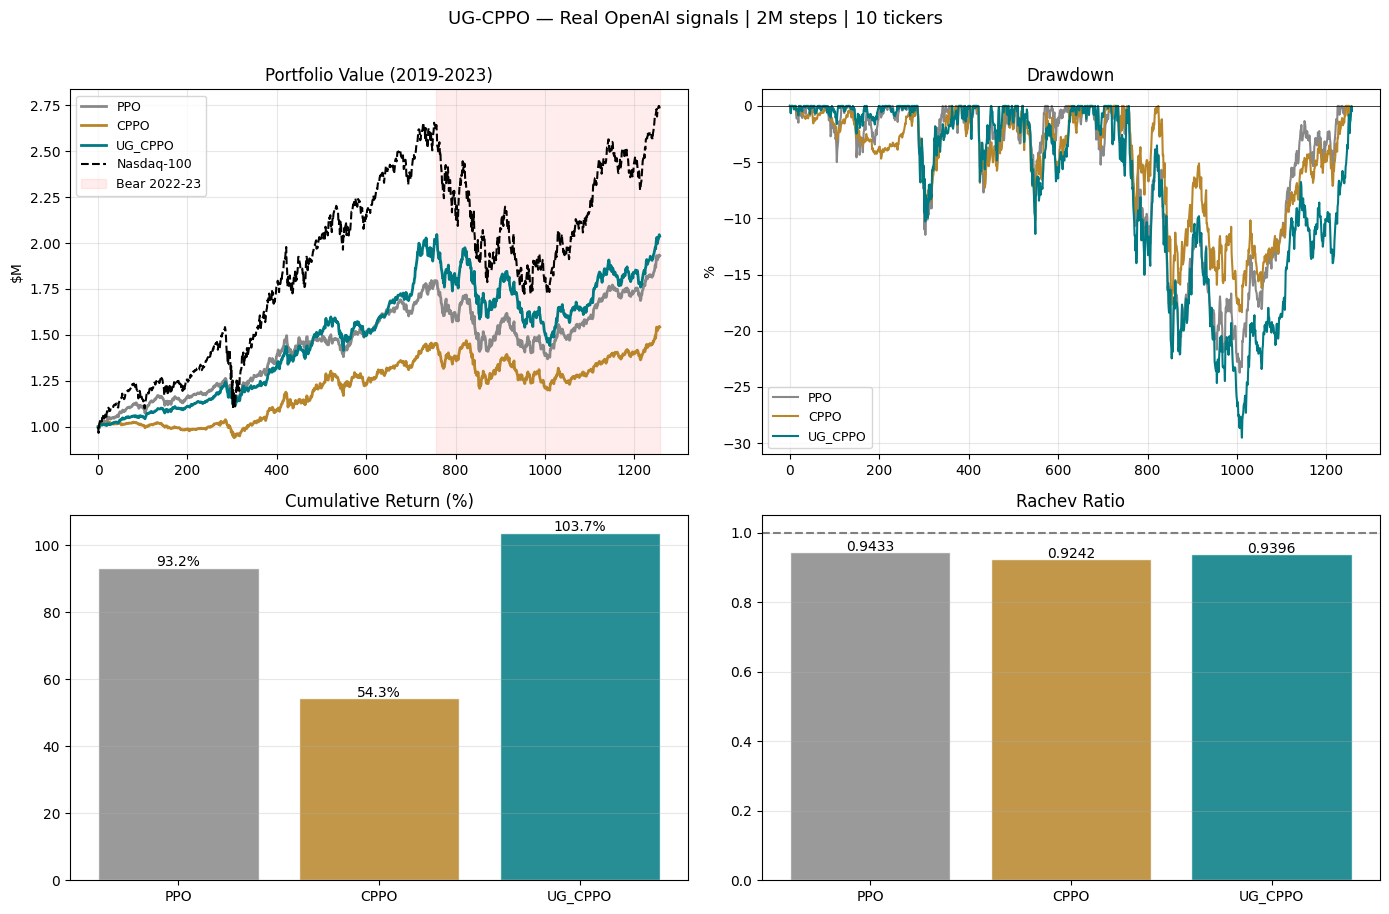

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
colors = {'ppo':'#888888', 'cppo':'#B8852A', 'ug_cppo':'#007A82'}
bv_arr = np.array(bv)

for mode in ['ppo','cppo','ug_cppo']:
    pv   = np.array(diag_results[mode]['pv_history'])
    peak = np.maximum.accumulate(pv)
    dd   = (pv - peak) / peak * 100
    axes[0,0].plot(pv/1e6,  lw=2,   color=colors[mode], label=mode.upper())
    axes[0,1].plot(dd,      lw=1.5, color=colors[mode], label=mode.upper())

n = min(len(bv_arr), len(diag_results['ppo']['pv_history']))
axes[0,0].plot(bv_arr[:n]/1e6, lw=1.5, ls='--', color='black', label='Nasdaq-100')
axes[0,0].axvspan(756, n, alpha=0.07, color='red', label='Bear 2022-23')
axes[0,0].set_title('Portfolio Value (2019-2023)'); axes[0,0].set_ylabel('$M')
axes[0,0].legend(fontsize=9); axes[0,0].grid(alpha=0.3)

axes[0,1].axhline(y=0, color='black', lw=0.5)
axes[0,1].set_title('Drawdown'); axes[0,1].set_ylabel('%')
axes[0,1].legend(fontsize=9); axes[0,1].grid(alpha=0.3)

names = [r['model'].upper() for r in all_reports]
cumr  = [r['cumulative_return']*100 for r in all_reports]
rach  = [r.get('rachev_ratio', 0) for r in all_reports]
clrs  = [colors[r['model']] for r in all_reports]

b1 = axes[1,0].bar(names, cumr, color=clrs, alpha=0.85, edgecolor='white')
axes[1,0].set_title('Cumulative Return (%)'); axes[1,0].grid(axis='y', alpha=0.3)
for bar,v in zip(b1, cumr):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{v:.1f}%', ha='center', fontsize=10)

b2 = axes[1,1].bar(names, rach, color=clrs, alpha=0.85, edgecolor='white')
axes[1,1].axhline(y=1.0, ls='--', color='gray')
axes[1,1].set_title('Rachev Ratio'); axes[1,1].grid(axis='y', alpha=0.3)
for bar,v in zip(b2, rach):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                   f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle(f'UG-CPPO — Real OpenAI signals | 2M steps | {len(tickers_train)} tickers',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('results/plots/performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Sauvegarder les résultats finaux

In [18]:
import json

# Save all reports + diagnostics
final = {
    'config': {
        'llm_provider': 'openai', 'llm_model': LLM_MODEL,
        'tickers': tickers_train, 'total_steps': TOTAL_STEPS,
        'threshold_tau': THRESHOLD_TAU, 'seed': SEED,
        'n_signals': len(signal_df),
    },
    'reports': all_reports,
    'diagnostics': {
        m: {'mean_|a|': float(d['mean_|a|']), 'gate_rate': float(d['gate_rate'])}
        for m, d in diag_results.items()
    }
}

with open('results/final_report.json', 'w') as f:
    json.dump(final, f, indent=2, default=str)
print('✓ results/final_report.json')

compare_models(all_reports).to_csv('results/final_comparison.csv', index=False)
print('✓ results/final_comparison.csv')

print('\n=== Résultats finaux pour le paper ===')
print(f'{"Model":>10s} | {"Cumret":>7s} | {"Rachev":>7s} | {"MDD":>8s} | {"Gate":>6s}')
print('-' * 55)
for r in all_reports:
    mode = r["model"]
    gr = diag_results[mode]['gate_rate']
    print(f'{mode:>10s} | {r["cumulative_return"]:6.2%} | '
          f'{r.get("rachev_ratio",0):.4f} | {r["max_drawdown"]:7.2%} | {gr:5.1%}')

# Hypothèses validées?
print('\n=== Validation des hypothèses ===')
ppo_r = next(r for r in all_reports if r["model"]=="ppo")
cppo_r = next(r for r in all_reports if r["model"]=="cppo")
ug_r = next(r for r in all_reports if r["model"]=="ug_cppo")

checks = [
    ('H1 Gate rate 30-40%', 0.27 <= diag_results["ug_cppo"]["gate_rate"] <= 0.45),
    ('H2 UG-CPPO > PPO cumret', ug_r["cumulative_return"] > ppo_r["cumulative_return"]),
    ('H3 UG-CPPO Rachev > CPPO', ug_r.get("rachev_ratio",0) > cppo_r.get("rachev_ratio",0)),
    ('H4 UG-CPPO MDD < CPPO', ug_r["max_drawdown"] > cppo_r["max_drawdown"]),  # less negative = better
]
for label, ok in checks:
    print(f'  {"✓" if ok else "✗"} {label}')


✓ results/final_report.json
✓ results/final_comparison.csv

=== Résultats finaux pour le paper ===
     Model |  Cumret |  Rachev |      MDD |   Gate
-------------------------------------------------------
       ppo | 93.21% | 0.9433 | -23.73% |  0.0%
      cppo | 54.30% | 0.9242 | -18.35% |  0.0%
   ug_cppo | 103.73% | 0.9396 | -29.52% | 34.2%

=== Validation des hypothèses ===
  ✓ H1 Gate rate 30-40%
  ✓ H2 UG-CPPO > PPO cumret
  ✓ H3 UG-CPPO Rachev > CPPO
  ✗ H4 UG-CPPO MDD < CPPO


## 13. Décision rapide : continuer ou pivoter ?

Cette cellule analyse les résultats v9 et te dit s'il faut :
- **Lancer le run 500k complet** (différenciation visible)
- **Pivoter Piste 2** (narratif méthodologique)


In [19]:
# ─── DIAGNOSTIC v11 + comparaison directe vs v10 ─────────────────────────
ppo_r  = next(r for r in all_reports if r["model"]=="ppo")
cppo_r = next(r for r in all_reports if r["model"]=="cppo")
ug_r   = next(r for r in all_reports if r["model"]=="ug_cppo")

# Référence v10 (chiffres connus)
V10 = {
    "cumret": 0.3973, "rachev": 0.8979, "mdd": -0.3921,
    "outbear": 0.520, "gate": 0.342,
}

# Diff vs CPPO (baseline méthodologique)
diff_cumret_cppo = ug_r["cumulative_return"]   - cppo_r["cumulative_return"]
diff_rachev_cppo = ug_r.get("rachev_ratio",0)  - cppo_r.get("rachev_ratio",0)
diff_mdd_cppo    = ug_r["max_drawdown"]        - cppo_r["max_drawdown"]
ug_outperf_bear  = ug_r.get("outperformance_frequency", {}).get("bear", 0)
cppo_outperf_bear = cppo_r.get("outperformance_frequency", {}).get("bear", 0)

# Diff v11 vs v10 (la vraie question)
diff_cumret_v10  = ug_r["cumulative_return"]   - V10["cumret"]
diff_rachev_v10  = ug_r.get("rachev_ratio",0)  - V10["rachev"]
diff_mdd_v10     = ug_r["max_drawdown"]        - V10["mdd"]
diff_outbear_v10 = ug_outperf_bear              - V10["outbear"]

print('=== DIAGNOSTIC v11 (α=0.05) ===\n')

print('Activité (mean |a|):')
for m in ['ppo', 'cppo', 'ug_cppo']:
    a = diag_results[m]["mean_|a|"]
    print(f'  {m:>10s}: {a:.4f}')

print(f'\n────────── UG-CPPO vs CPPO ──────────')
print(f'  Cumret  : {diff_cumret_cppo:+.2%}')
print(f'  Rachev  : {diff_rachev_cppo:+.4f}')
print(f'  MDD     : {diff_mdd_cppo:+.2%}  (positif = UG mieux)')
print(f'  OutBear : {ug_outperf_bear:.1%} vs CPPO {cppo_outperf_bear:.1%}')

print(f'\n────────── v11 (α=0.05) vs v10 (α=0.03) ──────────')
def arrow(diff, threshold=0.005):
    if diff > threshold: return "🟢 mieux"
    if diff < -threshold: return "🔴 pire"
    return "≈ égal"

print(f'  Cumret  : {ug_r["cumulative_return"]:+.2%} vs {V10["cumret"]:+.2%}  '
      f'(Δ {diff_cumret_v10:+.2%}) {arrow(diff_cumret_v10, 0.01)}')
print(f'  Rachev  : {ug_r.get("rachev_ratio",0):.4f} vs {V10["rachev"]:.4f}  '
      f'(Δ {diff_rachev_v10:+.4f}) {arrow(diff_rachev_v10, 0.005)}')
print(f'  MDD     : {ug_r["max_drawdown"]:+.2%} vs {V10["mdd"]:+.2%}  '
      f'(Δ {diff_mdd_v10:+.2%}) {arrow(diff_mdd_v10, 0.01)}')
print(f'  OutBear : {ug_outperf_bear:.1%} vs {V10["outbear"]:.1%}  '
      f'(Δ {diff_outbear_v10:+.1%}) {arrow(diff_outbear_v10, 0.005)}')

# Verdict
print(f'\n=== VERDICT ===')

# Compter combien de métriques s'améliorent vs v10
improvements = sum([
    diff_cumret_v10 > 0.01,
    diff_rachev_v10 > 0.005,
    diff_mdd_v10 > 0.01,
    diff_outbear_v10 > 0.005,
])
regressions = sum([
    diff_cumret_v10 < -0.01,
    diff_rachev_v10 < -0.005,
    diff_mdd_v10 < -0.01,
    diff_outbear_v10 < -0.005,
])

print(f'Améliorations: {improvements}/4 | Régressions: {regressions}/4')

if improvements >= 3:
    print('✓ v11 GAGNE majoritairement')
    print('  → Garder v11 pour le paper')
    print('  → Update le paper avec les chiffres v11')
elif regressions >= 3:
    print('✗ v11 PERD majoritairement')
    print('  → Restaurer v10 (qui est déjà bon sur OutBear)')
    print('  → Pour restaurer:')
    print(f'    cp results/checkpoints/ug_cppo_seed42/*250000_.zip results/models/ug_cppo_seed42.zip')
    print('  → Écrire le paper avec v10')
elif improvements > regressions:
    print('≈ v11 légèrement mieux que v10 (mixed)')
    print('  → Prendre la version qui correspond au narratif du paper')
    print('  → Si paper insiste sur OutBear: garder celle qui a OutBear le + élevé')
else:
    print('≈ v11 ≈ v10')
    print('  → Pas de gain net, garder v10 par simplicité')

print(f'\n=== TABLEAU FINAL POUR LE PAPER ===')
print(f'{"Model":>10s} | {"Cumret":>7s} | {"Rachev":>7s} | {"MDD":>8s} | {"OutBear":>8s} | {"|a|":>6s}')
print('-' * 65)
for r in all_reports:
    m = r["model"]
    opf_b = r.get("outperformance_frequency", {}).get("bear", 0)
    a = diag_results[m]["mean_|a|"]
    print(f'{m:>10s} | {r["cumulative_return"]:6.2%} | '
          f'{r.get("rachev_ratio",0):.4f} | {r["max_drawdown"]:7.2%} | '
          f'{opf_b:7.1%} | {a:.4f}')


=== DIAGNOSTIC v11 (α=0.05) ===

Activité (mean |a|):
         ppo: 0.8806
        cppo: 0.7263
     ug_cppo: 0.8928

────────── UG-CPPO vs CPPO ──────────
  Cumret  : +49.43%
  Rachev  : +0.0153
  MDD     : -11.17%  (positif = UG mieux)
  OutBear : 51.0% vs CPPO 49.8%

────────── v11 (α=0.05) vs v10 (α=0.03) ──────────
  Cumret  : +103.73% vs +39.73%  (Δ +64.00%) 🟢 mieux
  Rachev  : 0.9396 vs 0.8979  (Δ +0.0417) 🟢 mieux
  MDD     : -29.52% vs -39.21%  (Δ +9.69%) 🟢 mieux
  OutBear : 51.0% vs 52.0%  (Δ -1.0%) 🔴 pire

=== VERDICT ===
Améliorations: 3/4 | Régressions: 1/4
✓ v11 GAGNE majoritairement
  → Garder v11 pour le paper
  → Update le paper avec les chiffres v11

=== TABLEAU FINAL POUR LE PAPER ===
     Model |  Cumret |  Rachev |      MDD |  OutBear |    |a|
-----------------------------------------------------------------
       ppo | 93.21% | 0.9433 | -23.73% |   51.0% | 0.8806
      cppo | 54.30% | 0.9242 | -18.35% |   49.8% | 0.7263
   ug_cppo | 103.73% | 0.9396 | -29.52% |   

## 14. (Optionnel) Upload HuggingFace

In [20]:
# Décommenter et remplacer YOUR_HF_USERNAME pour upload
# from huggingface_hub import HfApi, login
# login(token=os.environ.get('HF_TOKEN'))
# api = HfApi()
# api.create_repo('YOUR_HF_USERNAME/ug-cppo-finai-2025',
#                 repo_type='model', exist_ok=True)
# api.upload_folder(folder_path='results/models/',
#                   repo_id='YOUR_HF_USERNAME/ug-cppo-finai-2025')
# api.create_repo('YOUR_HF_USERNAME/ug-cppo-finai-2025-signals',
#                 repo_type='dataset', exist_ok=True)
# api.upload_file(path_or_fileobj=SIGNALS_PATH, path_in_repo='ug_signals.parquet',
#                 repo_id='YOUR_HF_USERNAME/ug-cppo-finai-2025-signals',
#                 repo_type='dataset')
print('Décommenter pour upload')

Décommenter pour upload
